In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a mock dataset representing new user account creations and transaction traits
platform_data = {
    'User_ID': ['USR_1001', 'USR_1002', 'USR_1003', 'USR_1004', 'USR_1005', 'USR_1006'],
    'Username': ['johndoe88', 'crypto_king99', 'freestyler_x', 'giftcard_buyer1', 'mary_smith', 'fast_checkout_alpha'],
    'IP_Country': ['MY', 'US', 'MY', 'VN', 'SG', 'RO'],
    'Billing_Country': ['MY', 'UK', 'MY', 'US', 'SG', 'UA'],
    'Login_Attempts_Velocity': [1, 7, 2, 9, 1, 12],
    'Payment_Method': ['Local_Credit_Card', 'Crypto', 'FPX', 'International_Gift_Card', 'Debit_Card', 'Crypto'],
    'Transaction_Amount_USD': [45.00, 1200.00, 15.50, 500.00, 82.00, 2500.00]
}

# Load data into a Pandas DataFrame
df = pd.DataFrame(platform_data)

# Display data frame structure to verify attributes
print("--- Raw Platform Ingestion Log ---")
df.head()

--- Raw Platform Ingestion Log ---


,User_ID,Username,IP_Country,Billing_Country,Login_Attempts_Velocity,Payment_Method,Transaction_Amount_USD
0,USR_1001,johndoe88,MY,MY,1,Local_Credit_Card,45.0
1,USR_1002,crypto_king99,US,UK,7,Crypto,1200.0
2,USR_1003,freestyler_x,MY,MY,2,FPX,15.5
3,USR_1004,giftcard_buyer1,VN,US,9,International_Gift_Card,500.0
4,USR_1005,mary_smith,SG,SG,1,Debit_Card,82.0


In [5]:
def calculate_fraud_risk(row):
    risk_score = 0
    
    # Rule 1: Country Mismatch Indicator (Geographic Anomaly)
    if row['IP_Country'] != row['Billing_Country']:
        risk_score += 35
        
    # Rule 2: High Login Velocity / Brute Force Check
    if row['Login_Attempts_Velocity'] > 5:
        risk_score += 25
    if row['Login_Attempts_Velocity'] > 10:
        risk_score += 15  # Additional penalty for extreme velocity
        
    # Rule 3: High-Risk Payment Instruments (e.g., untraceable assets)
    if row['Payment_Method'] in ['Crypto', 'International_Gift_Card']:
        risk_score += 25
        
    # Rule 4: Outlier Ticket Value Threshold
    if row['Transaction_Amount_USD'] > 1000.00:
        risk_score += 20
        
    return risk_score

# Apply the risk engine across the dataset rows
df['Risk_Score'] = df.apply(calculate_fraud_risk, axis=1)

# Categorize risk scores into operational action tiers
def assign_action_tier(score):
    if score >= 70:
        return 'Banned (Immediate Automated Action)'
    elif score >= 35:
        return 'Flagged (Human-in-the-Loop QA Review Required)'
    else:
        return 'Safe (Approved Workflow)'

df['Action_Tier'] = df['Risk_Score'].apply(assign_action_tier)

# Display the evaluation summary
df[['User_ID', 'Username', 'Risk_Score', 'Action_Tier']].sort_values(by='Risk_Score', ascending=False)

,User_ID,Username,Risk_Score,Action_Tier
5,USR_1006,fast_checkout_alpha,120,Banned (Immediate Automated Action)
1,USR_1002,crypto_king99,105,Banned (Immediate Automated Action)
3,USR_1004,giftcard_buyer1,85,Banned (Immediate Automated Action)
0,USR_1001,johndoe88,0,Safe (Approved Workflow)
2,USR_1003,freestyler_x,0,Safe (Approved Workflow)
4,USR_1005,mary_smith,0,Safe (Approved Workflow)


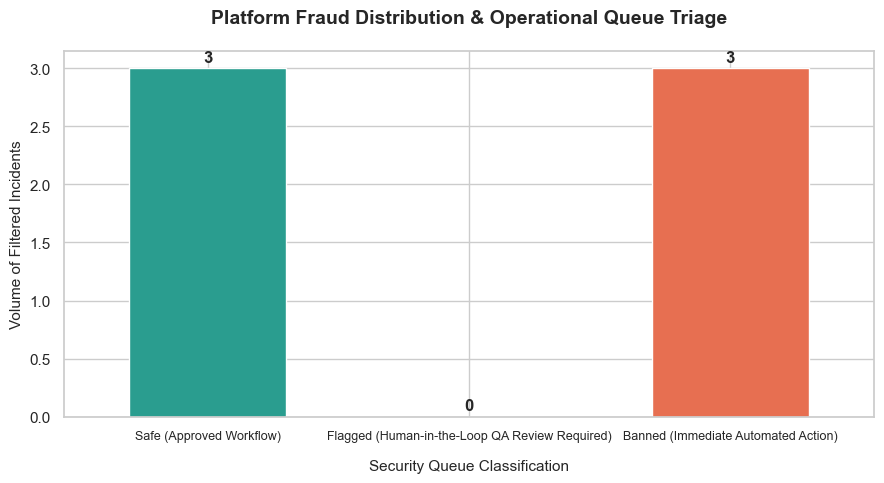

In [6]:
# Set visual parameters
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Group and count queue volumes per action tier
tier_counts = df['Action_Tier'].value_counts()
all_tiers = [
    'Safe (Approved Workflow)', 
    'Flagged (Human-in-the-Loop QA Review Required)', 
    'Banned (Immediate Automated Action)'
]
tier_counts = tier_counts.reindex(all_tiers, fill_value=0)

# Generate custom-themed color palette for risk states
colors = ['#2A9D8F', '#F4A261', '#E76F51'] # Teal, Orange, Deep Coral

# Plot data
ax = tier_counts.plot(kind='bar', color=colors, width=0.6)

# Formatting polish
plt.title('Platform Fraud Distribution & Operational Queue Triage', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Security Queue Classification', fontsize=11, labelpad=12)
plt.ylabel('Volume of Filtered Incidents', fontsize=11)
plt.xticks(rotation=0, ha='center', fontsize=9)

# Append values to top of bars for executive clarity
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()